In [31]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [32]:
emotion_df = pd.read_csv(r"C:\Users\LOQ\OneDrive\Desktop\NLP\data\emotions.csv")
violence_df = pd.read_csv(r"C:\Users\LOQ\OneDrive\Desktop\NLP\data\violence.csv")
hate_df = pd.read_csv(r"C:\Users\LOQ\OneDrive\Desktop\NLP\data\hatespeech.csv")

In [33]:
emotion_df.drop(columns = ['Unnamed: 0'],inplace=True)
violence_df.drop(columns = ['Tweet_ID'],inplace=True)
hate_df = hate_df[['tweet','class']]

In [34]:
emotion_df.head()

,text,label
0,i just feel really helpless and heavy hearted,4
1,ive enjoyed being able to slouch about relax a...,0
2,i gave up my internship with the dmrg and am f...,4
3,i dont know i feel so lost,0
4,i am a kindergarten teacher and i am thoroughl...,4


In [35]:
violence_df.head()

,tweet,type
0,Had a dream i got raped last night. By a guy i...,sexual_violence
1,he thought the word raped means sex and told m...,sexual_violence
2,She NOT TALKING TO ME I WAS RAPED BY 2 MEN 1 M...,sexual_violence
3,I was sexually abused for 3 years at age 4 to ...,sexual_violence
4,Chessy Prout can do better by telling the trut...,sexual_violence


In [36]:
hate_df.head()

,tweet,class
0,!!! RT @mayasolovely: As a woman you shouldn't...,2
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,1
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,1
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,1
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,1


In [37]:
emotion_df.columns, violence_df.columns, hate_df.columns

(Index(['text', 'label'], dtype='object'),
 Index(['tweet', 'type'], dtype='object'),
 Index(['tweet', 'class'], dtype='object'))

In [38]:
# Rename columns
violence_df.rename(columns={'tweet': 'text', 'type': 'label'}, inplace=True)
hate_df.rename(columns={'tweet': 'text', 'class': 'label'}, inplace=True)

In [39]:
emotion_df.columns, violence_df.columns, hate_df.columns

(Index(['text', 'label'], dtype='object'),
 Index(['text', 'label'], dtype='object'),
 Index(['text', 'label'], dtype='object'))

In [40]:
emotion_df.shape, violence_df.shape, hate_df.shape

((416809, 2), (39650, 2), (24783, 2))

In [41]:
emotion_df['label'].value_counts()

label
1    141067
0    121187
3     57317
4     47712
2     34554
5     14972
Name: count, dtype: int64

In [42]:
violence_df['label'].value_counts()

label
sexual_violence                 32648
Physical_violence                5946
emotional_violence                651
economic_violence                 217
Harmful_Traditional_practice      188
Name: count, dtype: int64

In [43]:
hate_df['label'].value_counts()

label
1    19190
2     4163
0     1430
Name: count, dtype: int64

In [44]:
# Reset index
emotion_df.reset_index(drop=True, inplace=True)
violence_df.reset_index(drop=True, inplace=True)
hate_df.reset_index(drop=True, inplace=True)

# CLASSIFICATION USING IMBALANCED DATASETS

In [45]:
# Label encoding for violence dataset
label_encoder = LabelEncoder()
violence_df['label'] = label_encoder.fit_transform(violence_df['label'])

In [46]:
violence_df['label'].value_counts()

label
4    32648
1     5946
3      651
2      217
0      188
Name: count, dtype: int64

In [47]:
'''
Emotions
0 : Sadness
1 : Joy
2 : Love
3 : Anger
4 : Fear
5 : Surprise

Violence
0 : Harmful_Traditional_practice
1 : Physical_violence 
2 : economic_violence
3 : emotional_violence  
4 : sexual_violence 

Hate
0 : Hate Speech
1 : Offensive Speech
2 : Neither

'''

'\nEmotions\n0 : Sadness\n1 : Joy\n2 : Love\n3 : Anger\n4 : Fear\n5 : Surprise\n\nViolence\n0 : Harmful_Traditional_practice\n1 : Physical_violence \n2 : economic_violence\n3 : emotional_violence  \n4 : sexual_violence \n\nHate\n0 : Hate Speech\n1 : Offensive Speech\n2 : Neither\n\n'

In [48]:
# Prepare labels
emotion_labels_text = ['Sadness', 'Joy', 'Love', 'Anger', 'Fear', 'Surprise']
violence_labels_text = ['Harmful Traditional Practice', 'Physical Violence', 'Economic Violence', 'Emotional Violence', 'Sexual Violence']
hate_labels_text = ['Hate Speech', 'Offensive Speech', 'Neither']

In [49]:
# ============================================================================
# TF-IDF VECTORIZATION
# ============================================================================

print("\nCreating TF-IDF features...")
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Fit on all text data
all_text = pd.concat([emotion_df['text'], violence_df['text'], hate_df['text']])
tfidf.fit(all_text)

# Transform datasets
X_emotion = tfidf.transform(emotion_df['text'])
y_emotion = emotion_df['label'].values

X_violence = tfidf.transform(violence_df['text'])
y_violence = violence_df['label'].values

X_hate = tfidf.transform(hate_df['text'])
y_hate = hate_df['label'].values



Creating TF-IDF features...


In [50]:
# Split data
print("Splitting data into train/test sets (80/20)...")
X_emotion_train, X_emotion_test, y_emotion_train, y_emotion_test = train_test_split(
    X_emotion, y_emotion, test_size=0.2, random_state=42, stratify=y_emotion
)

X_violence_train, X_violence_test, y_violence_train, y_violence_test = train_test_split(
    X_violence, y_violence, test_size=0.2, random_state=42, stratify=y_violence
)

X_hate_train, X_hate_test, y_hate_train, y_hate_test = train_test_split(
    X_hate, y_hate, test_size=0.2, random_state=42, stratify=y_hate
)

Splitting data into train/test sets (80/20)...


In [51]:
scores = []

In [52]:
def evaluate_model(model_name, emotion_pred, violence_pred, hate_pred):
    # Accuracy
    emotion_acc = accuracy_score(y_emotion_test, emotion_pred)
    violence_acc = accuracy_score(y_violence_test, violence_pred)
    hate_acc = accuracy_score(y_hate_test, hate_pred)
    overall_acc = (emotion_acc + violence_acc + hate_acc) / 3
    scores.append(overall_acc)

    # Precision
    emotion_prec = precision_score(y_emotion_test, emotion_pred, average='macro')
    violence_prec = precision_score(y_violence_test, violence_pred, average='macro')
    hate_prec = precision_score(y_hate_test, hate_pred, average='macro')
    overall_prec = (emotion_prec + violence_prec + hate_prec) / 3

    # Recall
    emotion_rec = recall_score(y_emotion_test, emotion_pred, average='macro')
    violence_rec = recall_score(y_violence_test, violence_pred, average='macro')
    hate_rec = recall_score(y_hate_test, hate_pred, average='macro')
    overall_rec = (emotion_rec + violence_rec + hate_rec) / 3

    # F1-score
    emotion_f1 = f1_score(y_emotion_test, emotion_pred, average='macro')
    violence_f1 = f1_score(y_violence_test, violence_pred, average='macro')
    hate_f1 = f1_score(y_hate_test, hate_pred, average='macro')
    overall_f1 = (emotion_f1 + violence_f1 + hate_f1) / 3
    
    # Print evaluation table
    print("\n" + "-"*75)
    print(f"{'CLASS':<15}{'ACCURACY':<15}{'PRECISION':<15}{'RECALL':<15}{'F1-SCORE':<15}")
    print("-"*75)

    print(f"{'Emotion':<15}{emotion_acc:<15.4f}{emotion_prec:<15.4f}{emotion_rec:<15.4f}{emotion_f1:<15.4f}")
    print(f"{'Violence':<15}{violence_acc:<15.4f}{violence_prec:<15.4f}{violence_rec:<15.4f}{violence_f1:<15.4f}")
    print(f"{'Hate Speech':<15}{hate_acc:<15.4f}{hate_prec:<15.4f}{hate_rec:<15.4f}{hate_f1:<15.4f}")

    print("-"*75)
    print(f"{'Overall Avg':<15}{overall_acc:<15.4f}{overall_prec:<15.4f}{overall_rec:<15.4f}{overall_f1:<15.4f}")
    print("-"*75)


In [67]:
def plot_confusion_matrices_subplot(emotion_pred, violence_pred, hate_pred, model_name):
    
    fig, axes = plt.subplots(
        1, 3,
        figsize=(18, 6),          # wider figure
        constrained_layout=True  # better than tight_layout
    )
    
    # ---------- Emotion ----------
    cm_emotion = confusion_matrix(y_emotion_test, emotion_pred, normalize='true')
    sns.heatmap(
        cm_emotion,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        xticklabels=emotion_labels_text,
        yticklabels=emotion_labels_text,
        ax=axes[0],
        #cbar_kws={'shrink': 0.75}
    )
    axes[0].set_title(f'{model_name}\nEmotion Classification', fontweight='bold')
    
    # ---------- Violence ----------
    cm_violence = confusion_matrix(y_violence_test, violence_pred, normalize='true')
    sns.heatmap(
        cm_violence,
        annot=True,
        fmt='.2f',
        cmap='Greens',
        xticklabels=violence_labels_text,
        yticklabels=violence_labels_text,
        ax=axes[1],
        #cbar_kws={'shrink': 0.75}
    )
    axes[1].set_title(f'{model_name}\nViolence Classification', fontweight='bold')
    
    # ---------- Hate Speech ----------
    cm_hate = confusion_matrix(y_hate_test, hate_pred, normalize='true')
    sns.heatmap(
        cm_hate,
        annot=True,
        fmt='.2f',
        cmap='Oranges',
        xticklabels=hate_labels_text,
        yticklabels=hate_labels_text,
        ax=axes[2],
        #cbar_kws={'shrink': 0.75}
    )
    axes[2].set_title(f'{model_name}\nHate Speech Classification', fontweight='bold')
    
    # ---------- Fix label overwriting ----------
    for ax in axes:
        ax.set_xticklabels(
            ax.get_xticklabels(),
            rotation=90,
            ha='center',
            va='top',
            fontsize=9
        )
        ax.set_yticklabels(
            ax.get_yticklabels(),
            rotation=0,
            ha='right',
            va='center',
            fontsize=9
        )
        ax.tick_params(axis='x', pad=6)  # space from axis
    
    plt.show()


In [54]:
# ============================================================================
# 1. RANDOM FOREST
# ============================================================================
print("\n" + "="*80)
print("TRAINING RANDOM FOREST CLASSIFIER")
print("="*80)

rf_emotion = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_violence = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_hate = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("Training models...")
rf_emotion.fit(X_emotion_train, y_emotion_train)
rf_violence.fit(X_violence_train, y_violence_train)
rf_hate.fit(X_hate_train, y_hate_train)

rf_emotion_pred = rf_emotion.predict(X_emotion_test)
rf_violence_pred = rf_violence.predict(X_violence_test)
rf_hate_pred = rf_hate.predict(X_hate_test)

evaluate_model('Random Forest', rf_emotion_pred, rf_violence_pred, rf_hate_pred)


TRAINING RANDOM FOREST CLASSIFIER
Training models...

---------------------------------------------------------------------------
CLASS          ACCURACY       PRECISION      RECALL         F1-SCORE       
---------------------------------------------------------------------------
Emotion        0.8471         0.7881         0.7937         0.7908         
Violence       0.9986         0.9994         0.9634         0.9800         
Hate Speech    0.8556         0.7365         0.5306         0.5578         
---------------------------------------------------------------------------
Overall Avg    0.9004         0.8413         0.7625         0.7762         
---------------------------------------------------------------------------


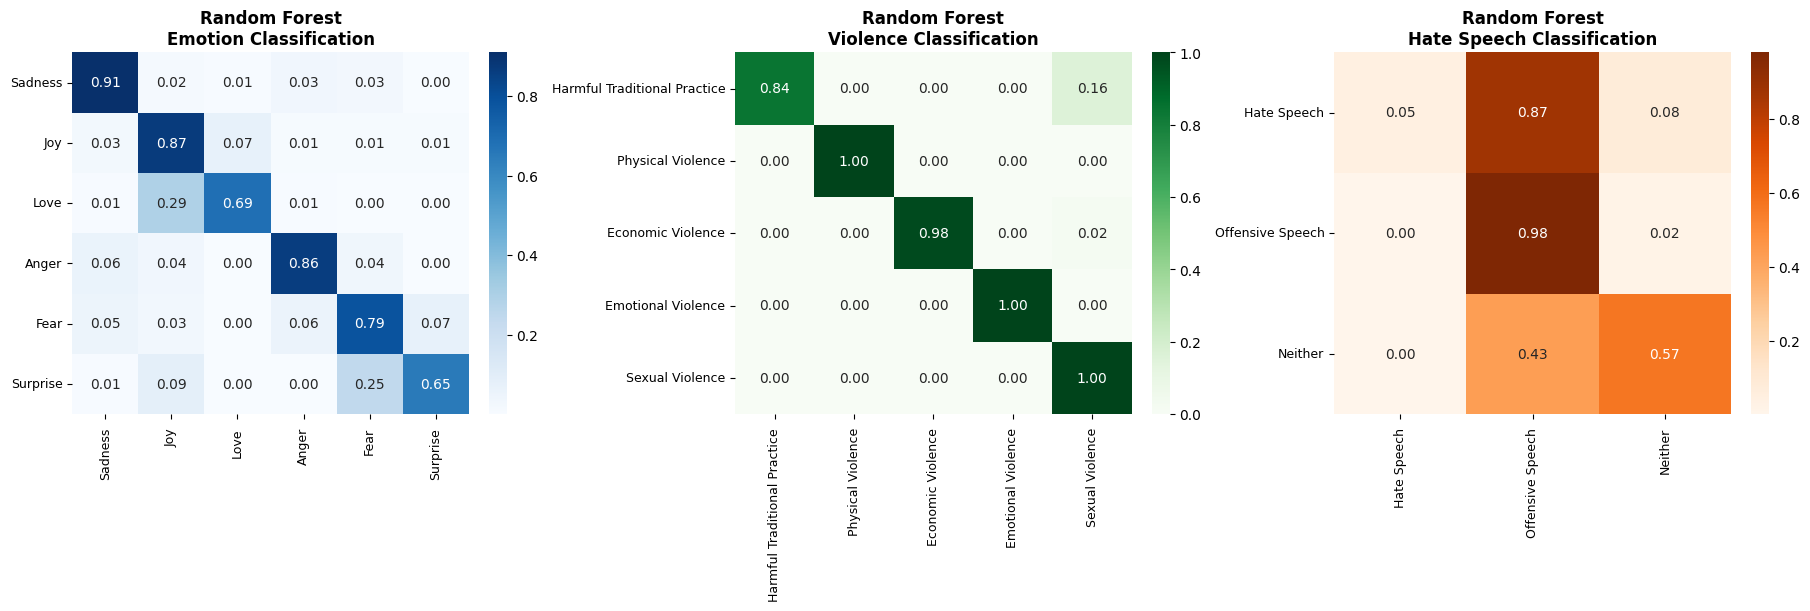

In [68]:
plot_confusion_matrices_subplot(rf_emotion_pred, rf_violence_pred, rf_hate_pred, 'Random Forest')

In [56]:
# ============================================================================
# 2. XGBOOST
# ============================================================================
print("\n" + "="*80)
print("TRAINING XGBOOST CLASSIFIER")
print("="*80)

xgb_emotion = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='mlogloss')
xgb_violence = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='mlogloss')
xgb_hate = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='mlogloss')

print("Training models...")
xgb_emotion.fit(X_emotion_train, y_emotion_train)
xgb_violence.fit(X_violence_train, y_violence_train)
xgb_hate.fit(X_hate_train, y_hate_train)

xgb_emotion_pred = xgb_emotion.predict(X_emotion_test)
xgb_violence_pred = xgb_violence.predict(X_violence_test)
xgb_hate_pred = xgb_hate.predict(X_hate_test)

evaluate_model('XGBoost', xgb_emotion_pred, xgb_violence_pred, xgb_hate_pred)


TRAINING XGBOOST CLASSIFIER
Training models...

---------------------------------------------------------------------------
CLASS          ACCURACY       PRECISION      RECALL         F1-SCORE       
---------------------------------------------------------------------------
Emotion        0.8876         0.8428         0.8771         0.8565         
Violence       0.9995         0.9984         0.9950         0.9967         
Hate Speech    0.8721         0.7318         0.6236         0.6402         
---------------------------------------------------------------------------
Overall Avg    0.9197         0.8577         0.8319         0.8311         
---------------------------------------------------------------------------


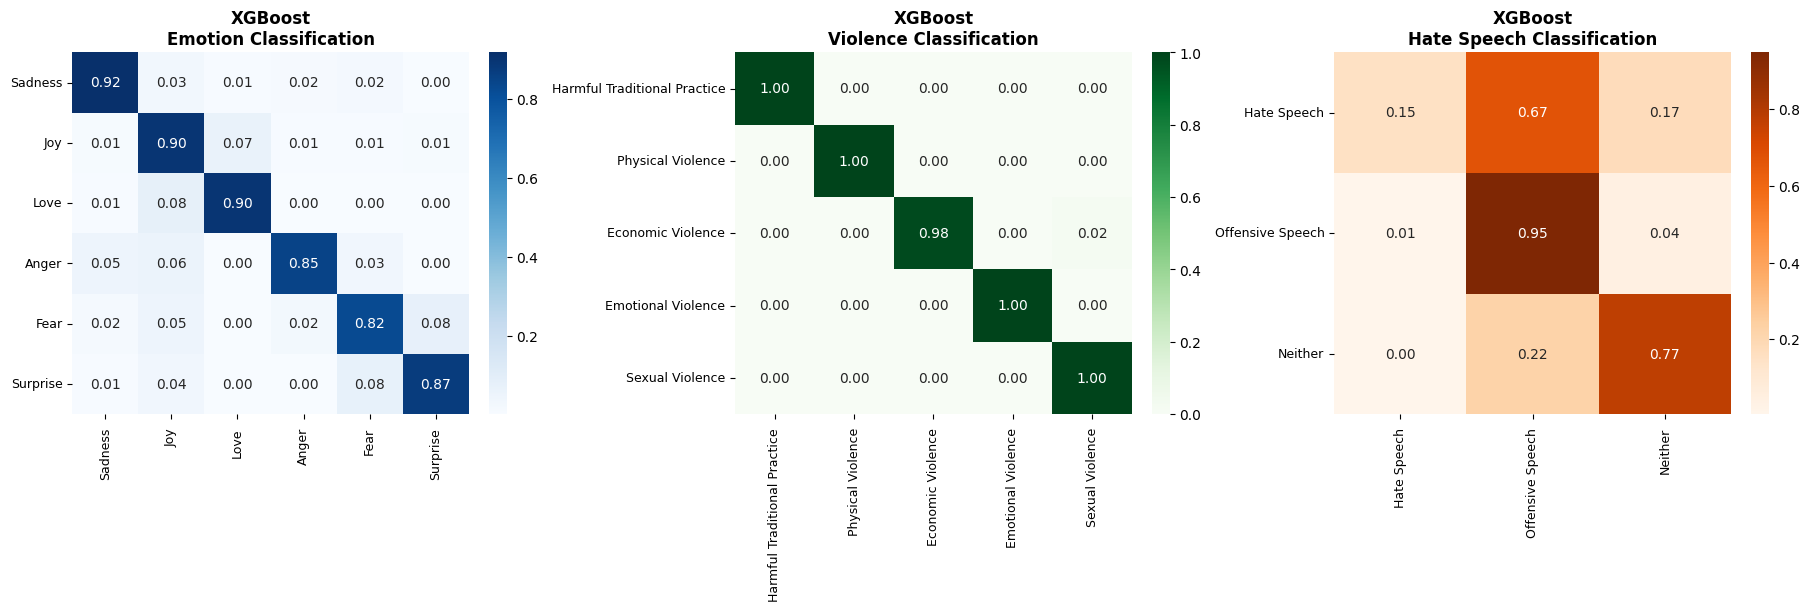

In [69]:
plot_confusion_matrices_subplot(xgb_emotion_pred, xgb_violence_pred, xgb_hate_pred, 'XGBoost')

In [58]:
# ============================================================================
# 3. SVM
# ============================================================================
print("\n" + "="*80)
print("TRAINING SVM CLASSIFIER")
print("="*80)

svm_emotion = SVC(kernel='linear', random_state=42)
svm_violence = SVC(kernel='linear', random_state=42)
svm_hate = SVC(kernel='linear', random_state=42)

print("Training models...")
svm_emotion.fit(X_emotion_train, y_emotion_train)
svm_violence.fit(X_violence_train, y_violence_train)
svm_hate.fit(X_hate_train, y_hate_train)

svm_emotion_pred = svm_emotion.predict(X_emotion_test)
svm_violence_pred = svm_violence.predict(X_violence_test)
svm_hate_pred = svm_hate.predict(X_hate_test)

evaluate_model('SVM', svm_emotion_pred, svm_violence_pred, svm_hate_pred)


TRAINING SVM CLASSIFIER
Training models...

---------------------------------------------------------------------------
CLASS          ACCURACY       PRECISION      RECALL         F1-SCORE       
---------------------------------------------------------------------------
Emotion        0.8882         0.8570         0.8293         0.8418         
Violence       0.9989         0.9865         0.9993         0.9928         
Hate Speech    0.8669         0.6488         0.5782         0.5691         
---------------------------------------------------------------------------
Overall Avg    0.9180         0.8308         0.8023         0.8012         
---------------------------------------------------------------------------


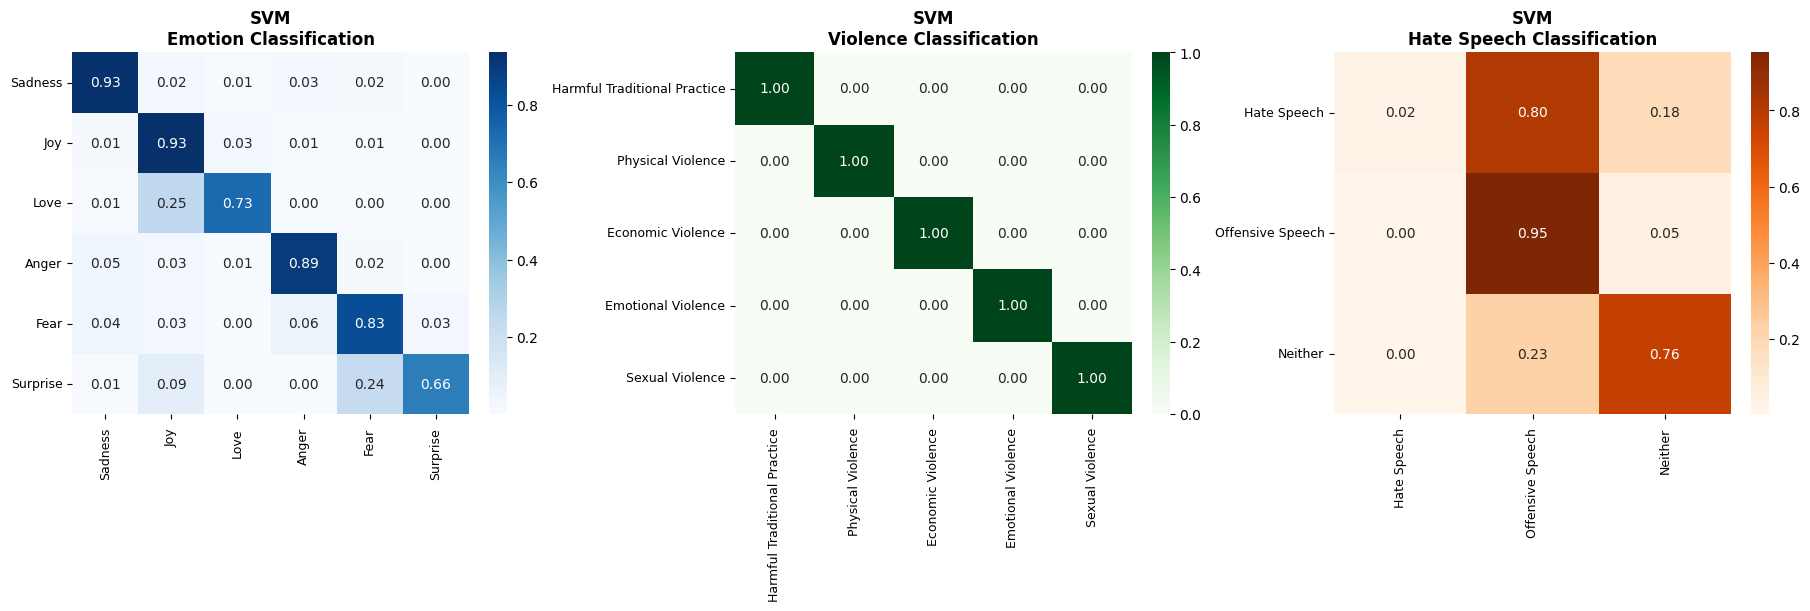

In [70]:
plot_confusion_matrices_subplot(svm_emotion_pred, svm_violence_pred, svm_hate_pred, 'SVM')

In [60]:
# ============================================================================
# 4. Complement Naive Bayes
# ============================================================================
print("\n" + "="*80)
print("TRAINING CNB CLASSIFIER")
print("="*80)

cnb_emotion = ComplementNB(alpha=0.1)
cnb_violence = ComplementNB(alpha=0.1)
cnb_hate = ComplementNB(alpha=0.1)

print("Training models...")
cnb_emotion.fit(X_emotion_train, y_emotion_train)
cnb_violence.fit(X_violence_train, y_violence_train)
cnb_hate.fit(X_hate_train, y_hate_train)

cnb_emotion_pred = cnb_emotion.predict(X_emotion_test)
cnb_violence_pred = cnb_violence.predict(X_violence_test)
cnb_hate_pred = cnb_hate.predict(X_hate_test)

evaluate_model('Complement Naive Bayes', cnb_emotion_pred, cnb_violence_pred, cnb_hate_pred)


TRAINING CNB CLASSIFIER
Training models...

---------------------------------------------------------------------------
CLASS          ACCURACY       PRECISION      RECALL         F1-SCORE       
---------------------------------------------------------------------------
Emotion        0.8934         0.8585         0.8622         0.8601         
Violence       0.9865         0.9950         0.7210         0.8094         
Hate Speech    0.7975         0.5700         0.6041         0.5783         
---------------------------------------------------------------------------
Overall Avg    0.8925         0.8078         0.7291         0.7493         
---------------------------------------------------------------------------


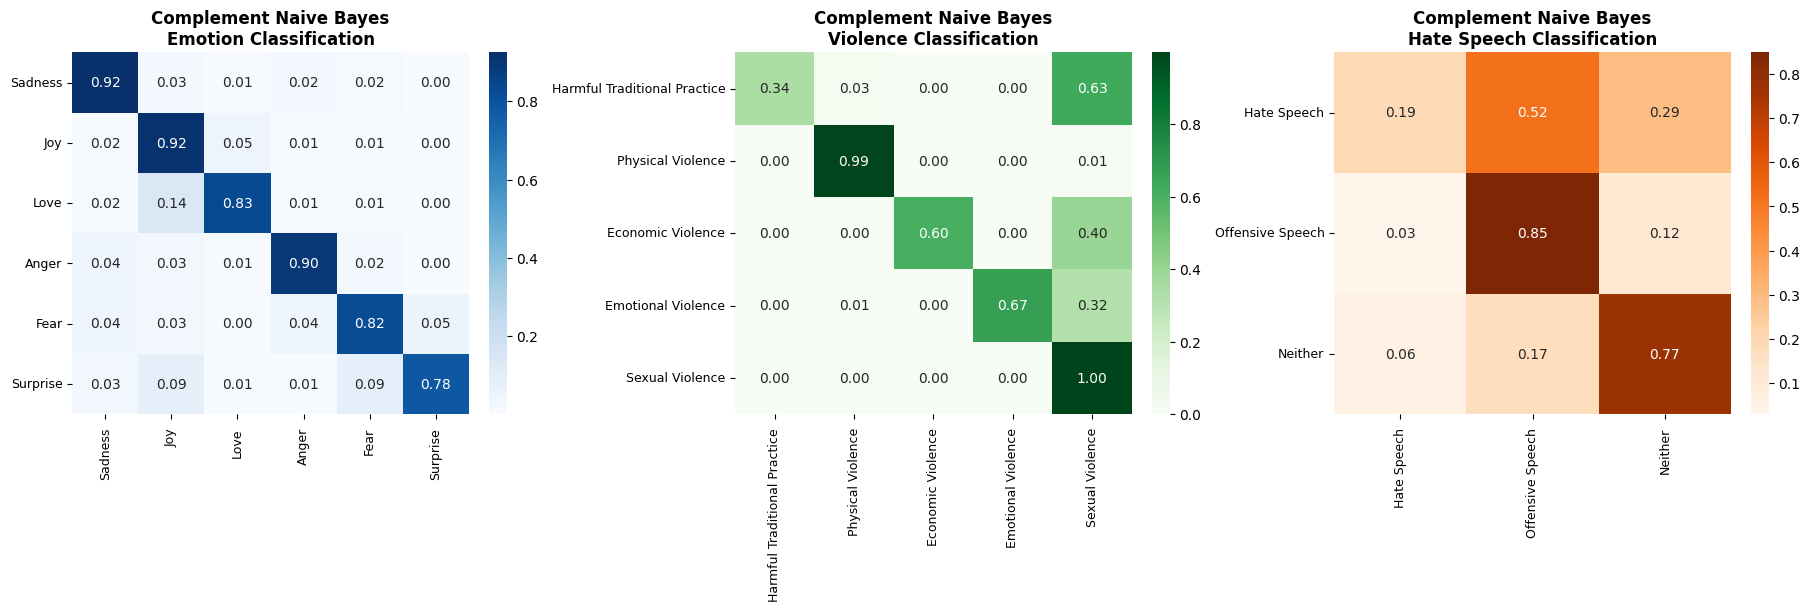

In [71]:
plot_confusion_matrices_subplot(cnb_emotion_pred, cnb_violence_pred, cnb_hate_pred, 'Complement Naive Bayes')

In [62]:
# ============================================================================
# 5. LIGHTGBM
# ============================================================================
print("\n" + "="*80)
print("TRAINING LIGHTGBM CLASSIFIER")
print("="*80)

lgbm_emotion = LGBMClassifier(n_estimators=200, random_state=42, n_jobs=-1, verbose=-1)
lgbm_violence = LGBMClassifier(n_estimators=200, random_state=42, n_jobs=-1, verbose=-1)
lgbm_hate = LGBMClassifier(n_estimators=200, random_state=42, n_jobs=-1, verbose=-1)

print("Training models...")
lgbm_emotion.fit(X_emotion_train, y_emotion_train)
lgbm_violence.fit(X_violence_train, y_violence_train)
lgbm_hate.fit(X_hate_train, y_hate_train)

lgbm_emotion_pred = lgbm_emotion.predict(X_emotion_test)
lgbm_violence_pred = lgbm_violence.predict(X_violence_test)
lgbm_hate_pred = lgbm_hate.predict(X_hate_test)

evaluate_model('LightGBM', lgbm_emotion_pred, lgbm_violence_pred, lgbm_hate_pred)


TRAINING LIGHTGBM CLASSIFIER
Training models...

---------------------------------------------------------------------------
CLASS          ACCURACY       PRECISION      RECALL         F1-SCORE       
---------------------------------------------------------------------------
Emotion        0.8964         0.8460         0.8682         0.8559         
Violence       0.9995         0.9882         0.9946         0.9914         
Hate Speech    0.8727         0.7322         0.6262         0.6438         
---------------------------------------------------------------------------
Overall Avg    0.9229         0.8555         0.8297         0.8303         
---------------------------------------------------------------------------


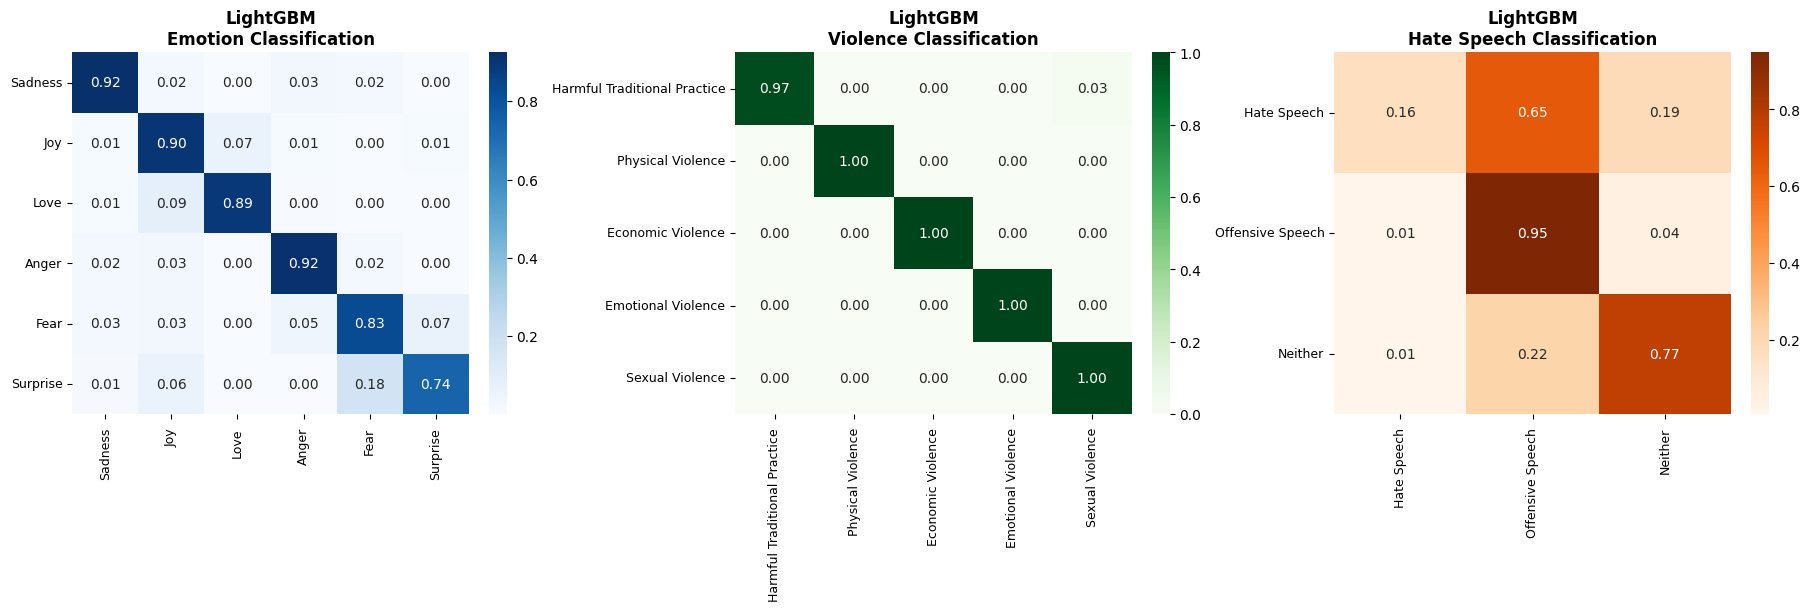

In [72]:
plot_confusion_matrices_subplot(lgbm_emotion_pred, lgbm_violence_pred, lgbm_hate_pred, 'LightGBM')

In [64]:
# ============================================================================
# 6. CATBOOST
# ============================================================================
# Initialize CatBoost models with optimal parameters
catboost_emotion = CatBoostClassifier(iterations=200, depth=8, learning_rate=0.1, loss_function='MultiClass', random_seed=42, verbose=False, thread_count=-1)
catboost_violence = CatBoostClassifier(iterations=200, depth=8, learning_rate=0.1, loss_function='MultiClass', random_seed=42, verbose=False, thread_count=-1)
catboost_hate = CatBoostClassifier(iterations=200, depth=8, learning_rate=0.1, loss_function='MultiClass', random_seed=42, verbose=False, thread_count=-1)

print("Training models...")
catboost_emotion.fit(X_emotion_train, y_emotion_train)
catboost_violence.fit(X_violence_train, y_violence_train)
catboost_hate.fit(X_hate_train, y_hate_train)

catboost_emotion_pred = catboost_emotion.predict(X_emotion_test)
catboost_violence_pred = catboost_violence.predict(X_violence_test)
catboost_hate_pred = catboost_hate.predict(X_hate_test)

evaluate_model('CatBoost', catboost_emotion_pred, catboost_violence_pred, catboost_hate_pred)

Training models...

---------------------------------------------------------------------------
CLASS          ACCURACY       PRECISION      RECALL         F1-SCORE       
---------------------------------------------------------------------------
Emotion        0.8661         0.8873         0.7842         0.8240         
Violence       0.9996         0.9948         0.9952         0.9949         
Hate Speech    0.8602         0.7521         0.5730         0.5974         
---------------------------------------------------------------------------
Overall Avg    0.9086         0.8781         0.7841         0.8054         
---------------------------------------------------------------------------


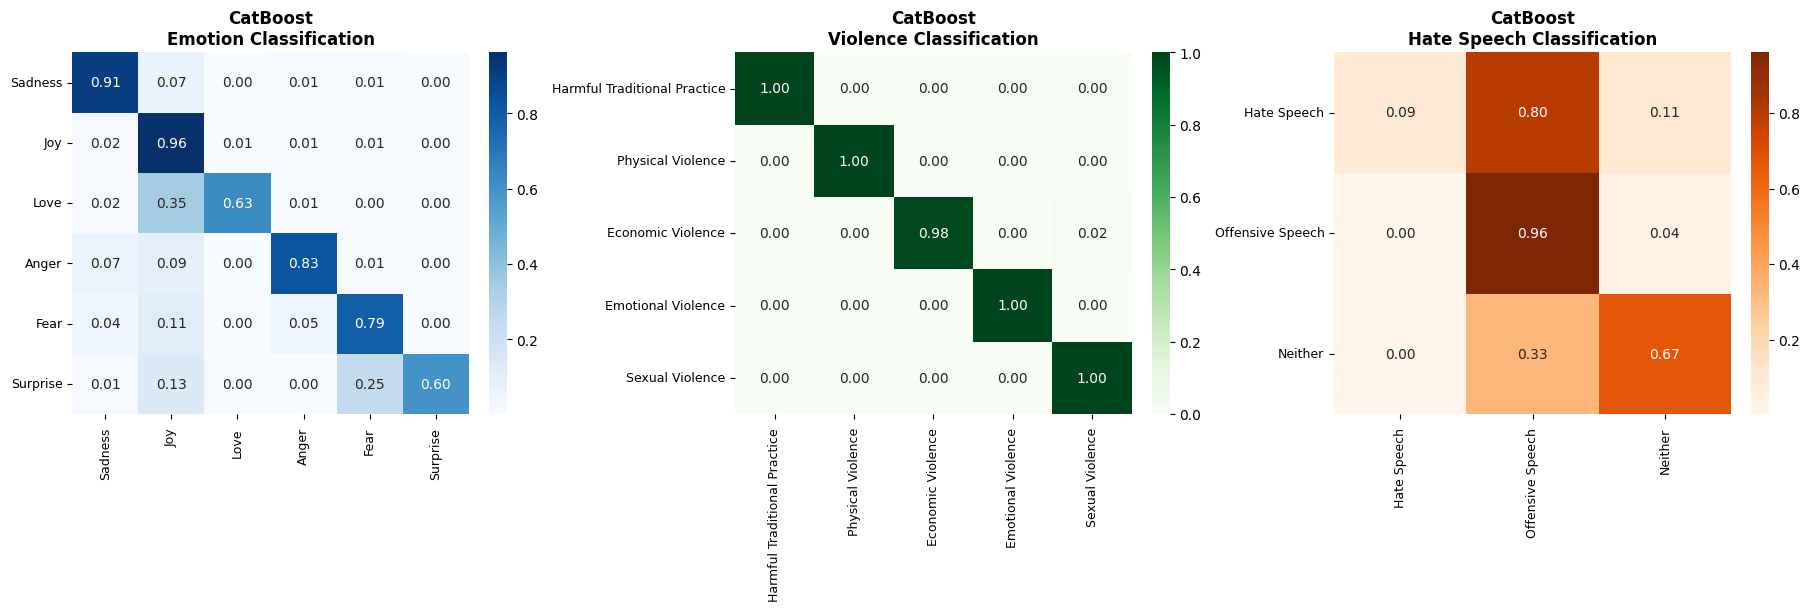

In [73]:
plot_confusion_matrices_subplot(catboost_emotion_pred, catboost_violence_pred, catboost_hate_pred, 'CatBoost')

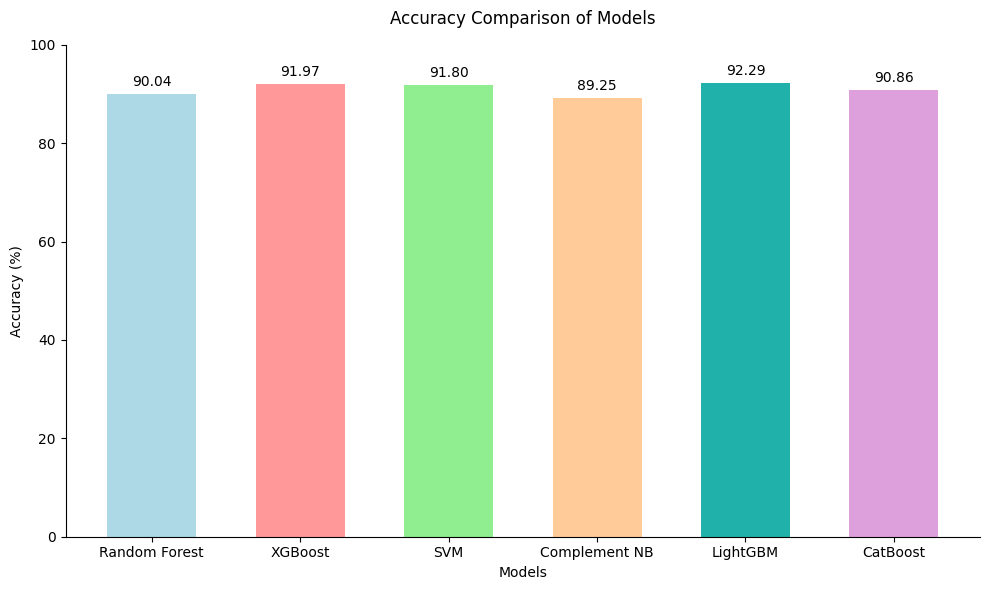

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['Random Forest','XGBoost','SVM','Complement NB','LightGBM','CatBoost']
acc = [90.04, 91.97, 91.80, 89.25, 92.29, 90.86]

# Pastel colors similar to your reference
colors = [
    '#ADD8E6',  # light blue
    '#FF9999',  # light red
    '#90EE90',  # light green
    '#FFCC99',  # light orange
    '#20B2AA',  # teal
    '#DDA0DD'   # plum
]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, acc, color=colors, width=0.6)

# Labels
plt.ylabel('Accuracy (%)')
plt.xlabel('Models')
plt.title('Accuracy Comparison of Models', pad=15)
# Y-axis range like reference
plt.ylim(0, 100)

# Remove top/right borders for clean look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Value labels on top of bars
for bar, value in zip(bars, acc):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{value:.2f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()


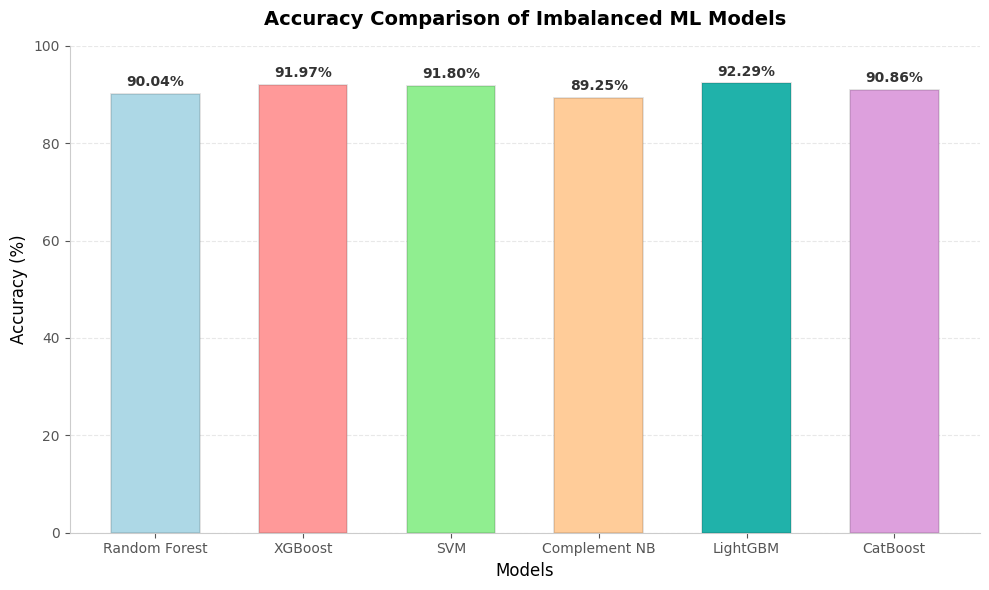

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['Random Forest','XGBoost','SVM','Complement NB','LightGBM','CatBoost']
acc = [90.04, 91.97, 91.80, 89.25, 92.29, 90.86]

# Pastel colors
colors = [
    '#ADD8E6',  # light blue
    '#FF9999',  # light red
    '#90EE90',  # light green
    '#FFCC99',  # light orange
    '#20B2AA',  # teal
    '#DDA0DD'   # plum
]

fig, ax = plt.subplots(figsize=(10, 6))

# Subtle horizontal grid
ax.yaxis.grid(True, color='#E8E8E8', linewidth=0.8, linestyle='--', zorder=0)
ax.set_axisbelow(True)

bars = ax.bar(models, acc, color=colors, width=0.6, zorder=3)

# Labels
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_xlabel('Models', fontsize=12)
ax.set_title('Accuracy Comparison of Imbalanced ML Models', pad=15, fontsize=14, fontweight='bold')

ax.set_ylim(0, 100)

# Remove top/right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.tick_params(axis='both', colors='#555555')

# Value labels on top of bars
for bar, value in zip(bars, acc):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{value:.2f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#333333'
    )

# Thin border outline on each bar for definition
for bar in bars:
    bar.set_edgecolor('#00000022')
    bar.set_linewidth(1.2)

plt.tight_layout()
plt.show()